In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Load data
df = pd.read_csv('product_monthly_panel.csv')

# Step 2: Pivot to wide format using the correct time column
wide_df = df.pivot(index='submission_time', columns='product_id', values='rating')



In [6]:
# Final Project Code: Pivot + Model Training (Fixed Version)

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Load data
df = pd.read_csv('product_monthly_panel.csv')

# Step 2: Pivot to wide format using correct time column
wide_df = df.pivot(index='submission_time', columns='product_id', values='rating')

# Step 3: Fill missing values
wide_df = wide_df.ffill().bfill()

# Step 4: Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(wide_df)

In [7]:
# Step 5: Create sequences
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 7
X, y = create_sequences(scaled_data, SEQ_LENGTH)

In [8]:
# Step 6: Train/Test split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [9]:
# Step 7: Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [10]:
# Step 8: Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


In [11]:
# Step 9: Define Models
class FNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class CNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=2)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=2)
        self.pool = nn.AdaptiveMaxPool1d(1)  # Automatically adapt size
        self.fc1 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


In [12]:
# Step 10: Train function
def train_model(model, train_loader, epochs=20):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()



In [13]:
# Step 11: Evaluate function
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
    mse = mean_squared_error(y_test.numpy(), y_pred.numpy())
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.numpy(), y_pred.numpy())
    return rmse, r2

input_dim = X_train_tensor.shape[2]
output_dim = y_train_tensor.shape[1]


In [14]:
# Train and Evaluate FNN
fnn = FNN(input_dim * SEQ_LENGTH, output_dim)
train_model(fnn, train_loader, epochs=50)
fnn_rmse, fnn_r2 = evaluate_model(fnn, X_test_tensor, y_test_tensor)


In [15]:
# Train and Evaluate CNN
cnn = CNN(input_dim, output_dim)
train_model(cnn, train_loader, epochs=20)
cnn_rmse, cnn_r2 = evaluate_model(cnn, X_test_tensor, y_test_tensor)


In [16]:
# Train and Evaluate LSTM
lstm = LSTMModel(input_dim, hidden_dim=50, output_dim=output_dim)
train_model(lstm, train_loader, epochs=20)
lstm_rmse, lstm_r2 = evaluate_model(lstm, X_test_tensor, y_test_tensor)



In [17]:
# Step 12: Print Results
print(f"FNN - RMSE: {fnn_rmse:.4f}, R2: {fnn_r2:.4f}")
print(f"CNN - RMSE: {cnn_rmse:.4f}, R2: {cnn_r2:.4f}")
print(f"LSTM - RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")


FNN - RMSE: 0.3267, R2: -8821489664.0000
CNN - RMSE: 0.3313, R2: -7989632000.0000
LSTM - RMSE: 0.3592, R2: -12946749440.0000


In [18]:
import matplotlib.pyplot as plt

# Step 13: Plot Loss Curves (for FNN, CNN, LSTM separately)

def get_loss_curve(model, train_loader, epochs=20):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
    return losses


In [19]:
# Get loss curves
fnn_loss_curve = get_loss_curve(FNN(input_dim * SEQ_LENGTH, output_dim), train_loader, epochs=50)
cnn_loss_curve = get_loss_curve(CNN(input_dim, output_dim), train_loader, epochs=20)
lstm_loss_curve = get_loss_curve(LSTMModel(input_dim, hidden_dim=50, output_dim=output_dim), train_loader, epochs=20)


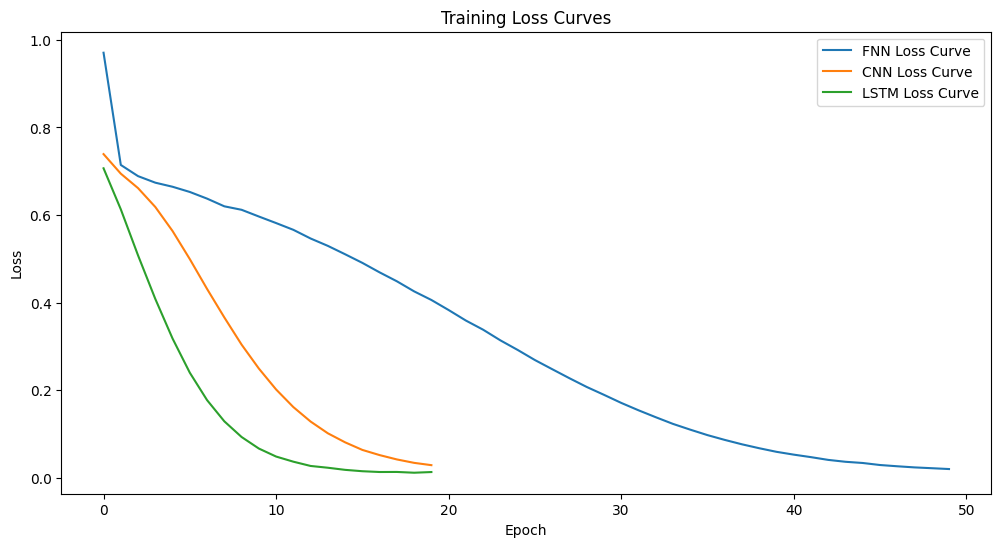

In [20]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(fnn_loss_curve, label='FNN Loss Curve')
plt.plot(cnn_loss_curve, label='CNN Loss Curve')
plt.plot(lstm_loss_curve, label='LSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.show()


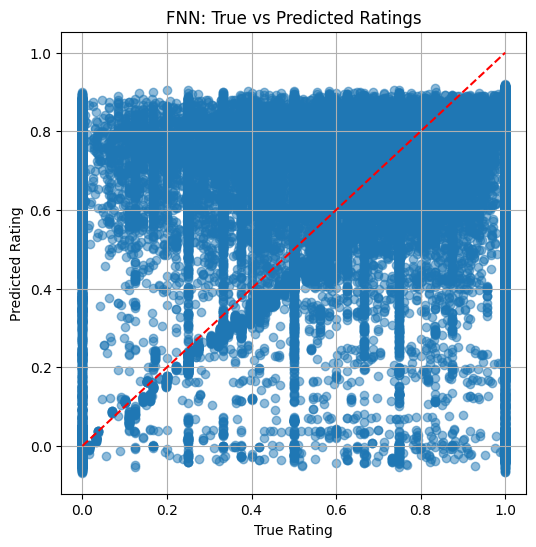

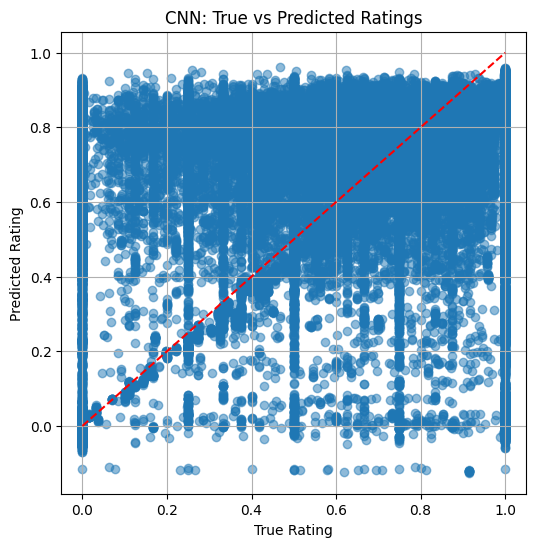

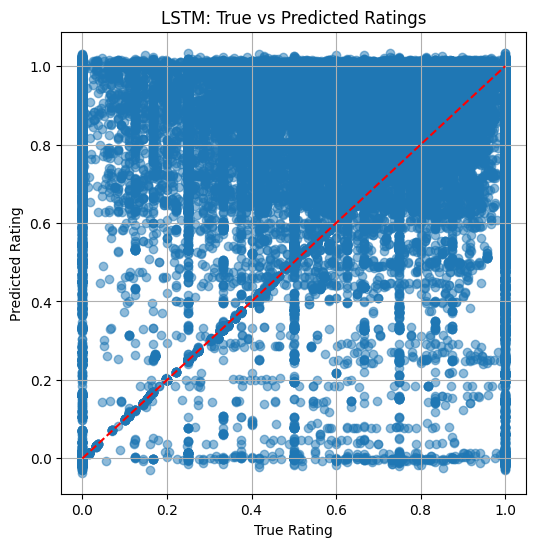

In [21]:
# Step 14: Plot True vs Predicted Ratings

def plot_predictions(model, X_test, y_test, model_name):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
    plt.figure(figsize=(6,6))
    plt.scatter(y_test.numpy().flatten(), y_pred.numpy().flatten(), alpha=0.5)
    plt.xlabel('True Rating')
    plt.ylabel('Predicted Rating')
    plt.title(f'{model_name}: True vs Predicted Ratings')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Line y=x
    plt.grid(True)
    plt.show()

plot_predictions(fnn, X_test_tensor, y_test_tensor, "FNN")
plot_predictions(cnn, X_test_tensor, y_test_tensor, "CNN")
plot_predictions(lstm, X_test_tensor, y_test_tensor, "LSTM")


In [22]:
# Step 15: Additional Evaluation Metrics

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def extra_metrics(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
    mae = mean_absolute_error(y_test.numpy(), y_pred.numpy())
    mape = mean_absolute_percentage_error(y_test.numpy(), y_pred.numpy())
    return mae, mape

fnn_mae, fnn_mape = extra_metrics(fnn, X_test_tensor, y_test_tensor)
cnn_mae, cnn_mape = extra_metrics(cnn, X_test_tensor, y_test_tensor)
lstm_mae, lstm_mape = extra_metrics(lstm, X_test_tensor, y_test_tensor)

print("\nAdditional Metrics:")
print(f"FNN - MAE: {fnn_mae:.4f}, MAPE: {fnn_mape:.4f}")
print(f"CNN - MAE: {cnn_mae:.4f}, MAPE: {cnn_mape:.4f}")
print(f"LSTM - MAE: {lstm_mae:.4f}, MAPE: {lstm_mape:.4f}")



Additional Metrics:
FNN - MAE: 0.2440, MAPE: 245274224099328.0000
CNN - MAE: 0.2432, MAPE: 249795214049280.0000
LSTM - MAE: 0.2284, MAPE: 291965098786816.0000


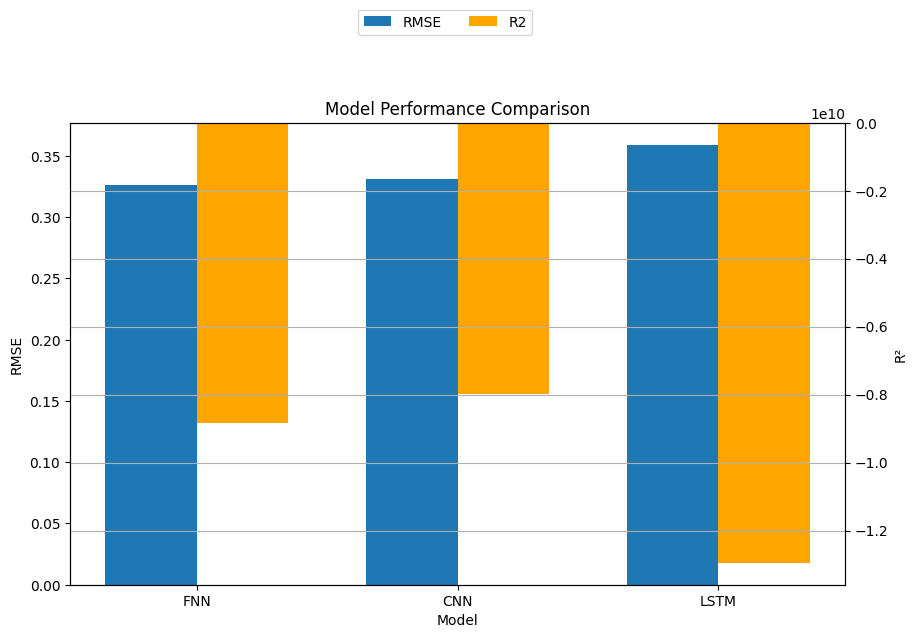

In [23]:
# Step 16: Compare RMSE and R2 Scores with Bar Chart

models = ['FNN', 'CNN', 'LSTM']
rmses = [fnn_rmse, cnn_rmse, lstm_rmse]
r2s = [fnn_r2, cnn_r2, lstm_r2]

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10,6))
ax2 = ax1.twinx()

ax1.bar(x - width/2, rmses, width, label='RMSE')
ax2.bar(x + width/2, r2s, width, color='orange', label='R2')

ax1.set_ylabel('RMSE')
ax2.set_ylabel('R²')
ax1.set_xlabel('Model')
ax1.set_title('Model Performance Comparison')

ax1.set_xticks(x)
ax1.set_xticklabels(models)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2)
plt.grid(True)
plt.show()

In [24]:
# Step 5: Create sequences (PREDICT CHANGE instead of raw rating)

def create_sequences_predict_change(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length - 1):
        x = data[i:i+seq_length]
        y = data[i+seq_length+1] - data[i+seq_length]  # DIFFERENCE between next day's rating and today's
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Replace this:
# X, y = create_sequences(scaled_data, SEQ_LENGTH)

# with this:
X, y = create_sequences_predict_change(scaled_data, SEQ_LENGTH)


In [25]:
# When evaluating, add the predicted change back to the last known rating
def evaluate_model_predict_change(model, X_test, y_test, X_raw_test):
    model.eval()
    with torch.no_grad():
        y_pred_change = model(X_test)
        y_pred_final = X_raw_test[:, -1, :] + y_pred_change  # Add predicted change to last input day
    mse = mean_squared_error(y_test.numpy(), y_pred_final.numpy())
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.numpy(), y_pred_final.numpy())
    return rmse, r2

# Example usage:
# rmse, r2 = evaluate_model_predict_change(fnn, X_test_tensor, y_test_tensor, X_test_tensor)


In [26]:
# Create sequences that predict the CHANGE in rating, not the raw rating
def create_sequences_predict_change(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length - 1):
        x = data[i:i+seq_length]
        y = data[i+seq_length+1] - data[i+seq_length]  # Predict change
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Create the new sequences
X, y = create_sequences_predict_change(scaled_data, SEQ_LENGTH)

# Split into train/test again
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to tensors again
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoaders again
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)



In [27]:
# Redefine evaluation to add the predicted change back
def evaluate_model_predict_change(model, X_test, y_test, X_raw_test):
    model.eval()
    with torch.no_grad():
        y_pred_change = model(X_test)
        y_pred_final = X_raw_test[:, -1, :] + y_pred_change  # Add predicted change to last rating
    mse = mean_squared_error(y_test.numpy(), y_pred_final.numpy())
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.numpy(), y_pred_final.numpy())
    return rmse, r2


In [28]:
# Retrain your models
fnn = FNN(X_train_tensor.shape[2] * SEQ_LENGTH, y_train_tensor.shape[1])
train_model(fnn, train_loader, epochs=50)
cnn = CNN(X_train_tensor.shape[2], y_train_tensor.shape[1])
train_model(cnn, train_loader, epochs=20)
lstm = LSTMModel(X_train_tensor.shape[2], hidden_dim=50, output_dim=y_train_tensor.shape[1])
train_model(lstm, train_loader, epochs=20)


In [29]:
# Evaluate with change prediction
fnn_rmse, fnn_r2 = evaluate_model_predict_change(fnn, X_test_tensor, y_test_tensor, X_test_tensor)
cnn_rmse, cnn_r2 = evaluate_model_predict_change(cnn, X_test_tensor, y_test_tensor, X_test_tensor)
lstm_rmse, lstm_r2 = evaluate_model_predict_change(lstm, X_test_tensor, y_test_tensor, X_test_tensor)


In [30]:
# Print new results
print(f"FNN - RMSE: {fnn_rmse:.4f}, R2: {fnn_r2:.4f}")
print(f"CNN - RMSE: {cnn_rmse:.4f}, R2: {cnn_r2:.4f}")
print(f"LSTM - RMSE: {lstm_rmse:.4f}, R2: {lstm_r2:.4f}")


FNN - RMSE: 0.8241, R2: -15.1286
CNN - RMSE: 0.8249, R2: -15.1219
LSTM - RMSE: 0.8244, R2: -15.1437
